In [1]:
install.packages("table1")

Installing package into ‘/home/jupyter/.R/library’
(as ‘lib’ is unspecified)



In [2]:
library(bigrquery)
library(knitr)
library(tidyverse)
library(ggplot2)
library("table1")
library("IRdisplay")
bq_auth()

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.3     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘table1’


The following objects are masked from ‘package:base’:

    units, units<-




In [3]:
data <-bq_dataset_query(query="
SELECT *

 FROM `yhcr-prd-phm-bia-core.CB_MYSPACE_RS.CAMHS_alt`"
                       ,x="yhcr-prd-phm-bia-core.CB_MYSPACE_RS")

CAMHS <- bq_table_download(data) 

In [4]:
head(CAMHS)

person_id,birth_datetime,ethnic_group,gender_source_value,dateevent,age_at_encounter,age_band,snomedcode,ctv3code,ctv3text,lsoa,partialpostcode,tbl_srpatientaddresshistory_start_date,tbl_srpatientaddresshistory_end_date,IMD,LSOA_Name,event_year
<int>,<dttm>,<chr>,<chr>,<dttm>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<dttm>,<int>,<chr>,<int>
13402329,2005-02-15,Unknown,Male,2012-02-10 00:00:01,7,5-10,514341000000108,XaXIf,Referral to safeguarding children team,E01010708,BD21,2012-04-10,2012-04-10,5,Bradford 006C E01010708,2012
10425851,1996-04-15,White,Male,2012-10-09 00:00:00,16,15-20,870791000000104,XaaCX,Discharge from child and adolescent mental health,E01027573,BD23,2014-09-12,2014-09-12,6,Craven 003D E01027573,2012
13603146,1997-03-15,White,Female,2012-09-12 00:00:00,15,15-20,870791000000104,XaaCX,Discharge from child and adolescent mental health service,E01027581,DG7,2016-05-18,2016-05-18,4,Craven 006C E01027581,2012
639289,2001-12-15,Asian or Asian British,Female,2012-02-10 00:00:01,11,10-15,514341000000108,XaXIf,Referral to safeguarding children team,E01010708,BD21,2012-02-03,2012-02-03,5,Bradford 006C E01010708,2012
11086524,2011-12-15,White,Male,2012-04-10 17:23:13,1,0-5,514341000000108,XaXIf,Referral to safeguarding children team,E01010759,YO32,2013-12-09,2013-12-09,3,Bradford 058F E01010759,2012
13347781,1996-08-15,White,Female,2012-02-22 10:38:33,16,15-20,514341000000108,XaXIf,Referral to safeguarding children team,E01010703,BD21,2004-12-16,2004-12-16,3,Bradford 008D E01010703,2012


In [5]:
data1 <-bq_dataset_query(query="
select round(avg(count1),5)

from(

SELECT person_id,count(person_id) count1

 FROM `yhcr-prd-phm-bia-core.CB_MYSPACE_RS.CAMHS_alt`

 group by person_id)base"
                       ,x="yhcr-prd-phm-bia-core.CB_MYSPACE_RS")

CAMHSAVG <- bq_table_download(data1) 

In [6]:
library(forcats)

In [7]:
display_jupyter <- function(x) {
  css <- system.file("table1_defaults_1.0/table1_defaults.css", package="table1")
  css <- paste(readLines(css), collapse="\n")
  x <- htmltools::tagList(htmltools::tags$style(css), htmltools::tags$div(class="Rtable1", x))
  IRdisplay::display_html(as.character(x))
}

In [8]:
CAMHS$age_band <- factor(CAMHS$age_band, levels = c("0-5", "5-10", "10-15", "15-20", "20-25", "25+"))

In [9]:
label(CAMHS$IMD)      <- "IMD"
label(CAMHS$ethnic_group)      <- "Ethnic Group"
label(CAMHS$gender_source_value)      <- "Gender"
label(CAMHS$age_band)      <- c("Age Band")

In [10]:
 x<-table1(~ CAMHS$IMD + CAMHS$ethnic_group +CAMHS$gender_source_value +CAMHS$age_band |CAMHS$event_year,data=CAMHS
          ,justify=c("left", "left", rep("center", 5)),format_number = TRUE
          ,caption = "COS-EY 3: Mental Health - Child and Adolescent Mental Health Services (CAMHS) referrals-and-discharges:
a demographic breakdown of a Bradford Primary Care sample from Connected Bradford using OpenCodelists Snomed Codes'"
         )
## Snomed Code derived by Dr Ciarán McInerney,Research Associate School of Medicine & Population Health, University of Sheffield. 
#This list of possible codes was generated by searching the SNOMED-CT vocabulary for the keywords 'CAMHS' and 'safeguarding'. The only authority this codelist has is the review by the clinical team members.
#https://www.opencodelists.org/codelist/user/ciaranmci/camhs-referrals-and-discharges/0e87f47d/


Warning message in table1.formula(~CAMHS$IMD + CAMHS$ethnic_group + CAMHS$gender_source_value + :
“Terms to the right of '|' in formula 'x' define table columns and are expected to be factors with meaningful labels.”
Warning message in .table1.internal(x = x, labels = labels, groupspan = groupspan, :
“Table has 13 columns. Are you sure this is what you want?”


In [11]:
display_jupyter(x)

,2012(N=10),2013(N=35),2014(N=65),2015(N=82),2016(N=74),2017(N=177),2018(N=218),2019(N=356),2020(N=414),2021(N=398),2022(N=403),2023(N=66),Overall(N=2298)
IMD,,,,,,,,,,,,,
Mean (SD),4.60 (1.07),2.54 (2.16),2.63 (2.23),3.20 (2.72),2.76 (2.37),3.77 (2.59),3.31 (2.66),3.46 (2.65),3.61 (2.80),3.54 (2.75),3.59 (2.75),2.97 (2.59),3.45 (2.69)
"Median [Min, Max]","5.00 [3.00, 6.00]","1.00 [1.00, 9.00]","1.00 [1.00, 9.00]","2.00 [1.00, 10.0]","2.00 [1.00, 9.00]","3.00 [1.00, 10.0]","2.00 [1.00, 10.0]","3.00 [1.00, 10.0]","2.50 [1.00, 10.0]","2.00 [1.00, 10.0]","3.00 [1.00, 10.0]","2.00 [1.00, 10.0]","2.00 [1.00, 10.0]"
Ethnic Group,,,,,,,,,,,,,
Asian or Asian British,3 (30.0%),5 (14.3%),11 (16.9%),17 (20.7%),11 (14.9%),22 (12.4%),36 (16.5%),60 (16.9%),56 (13.5%),87 (21.9%),69 (17.1%),12 (18.2%),389 (16.9%)
Unknown,1 (10.0%),10 (28.6%),9 (13.8%),11 (13.4%),7 (9.5%),29 (16.4%),32 (14.7%),33 (9.3%),43 (10.4%),48 (12.1%),26 (6.5%),9 (13.6%),258 (11.2%)
White,6 (60.0%),18 (51.4%),38 (58.5%),45 (54.9%),50 (67.6%),116 (65.5%),144 (66.1%),246 (69.1%),294 (71.0%),243 (61.1%),281 (69.7%),45 (68.2%),1526 (66.4%)
Mixed multiple ethnic groups,0 (0%),2 (5.7%),5 (7.7%),4 (4.9%),0 (0%),5 (2.8%),3 (1.4%),14 (3.9%),19 (4.6%),17 (4.3%),14 (3.5%),0 (0%),83 (3.6%)
Black or African or Caribbean or Black British,0 (0%),0 (0%),1 (1.5%),0 (0%),5 (6.8%),3 (1.7%),2 (0.9%),1 (0.3%),0 (0%),1 (0.3%),7 (1.7%),0 (0%),20 (0.9%)
Other ethnic group,0 (0%),0 (0%),1 (1.5%),5 (6.1%),1 (1.4%),2 (1.1%),1 (0.5%),2 (0.6%),2 (0.5%),2 (0.5%),6 (1.5%),0 (0%),22 (1.0%)


In [12]:
library(dplyr)

`summarise()` has grouped output by 'event_year'. You can override using the
`.groups` argument.


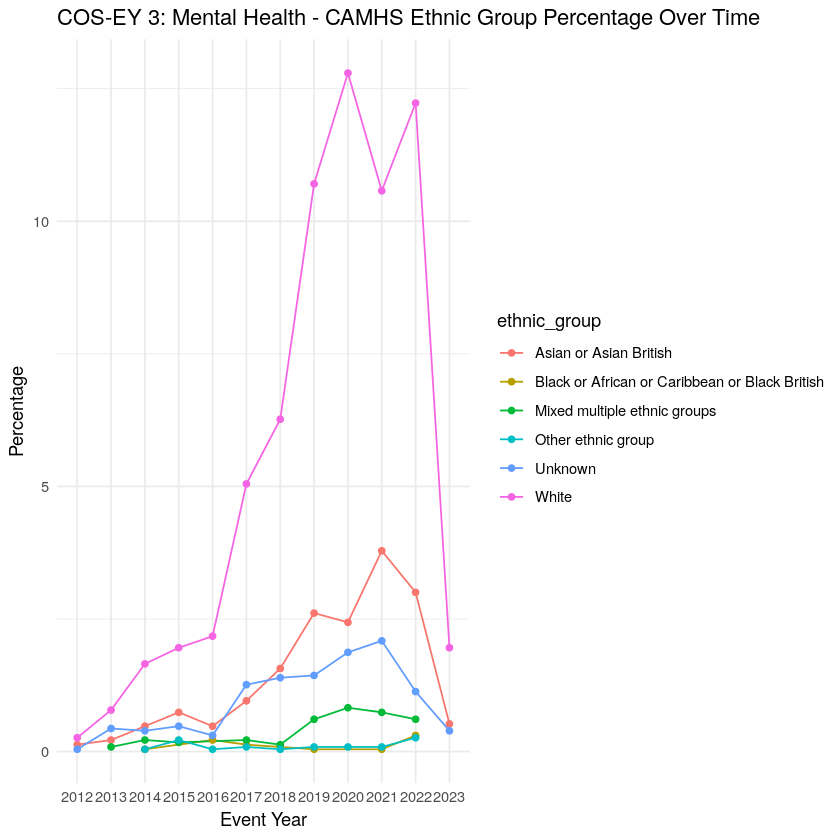

In [13]:
CAMHS_percentage <- CAMHS %>%
  group_by(event_year, ethnic_group) %>%
  summarise(percentage = n() / nrow(CAMHS) * 100)


CAMHS_percentage$event_year <- factor(CAMHS_percentage$event_year, levels = as.character(2012:2023))

ggplot(CAMHS_percentage, aes(x = event_year, y = percentage, group = ethnic_group, color = ethnic_group)) +
  geom_line() +
  geom_point() +
  labs(title = "COS-EY 3: Mental Health - CAMHS Ethnic Group Percentage Over Time",
       x = "Event Year",
       y = "Percentage") +
  theme_minimal()

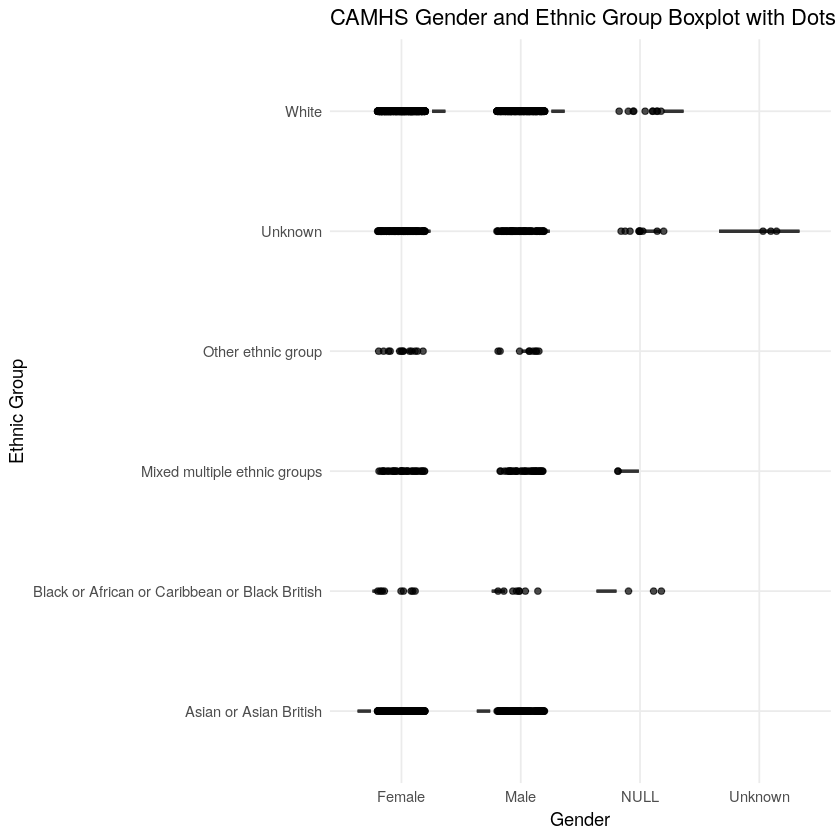

In [14]:
ggplot(CAMHS, aes(x = gender_source_value, y = ethnic_group)) +
  geom_boxplot() +
  geom_point(position = position_jitter(width = 0.2, height = 0), alpha = 0.7) +
  labs(title = "CAMHS Gender and Ethnic Group Boxplot with Dots",
       x = "Gender",
       y = "Ethnic Group") +
  theme_minimal()


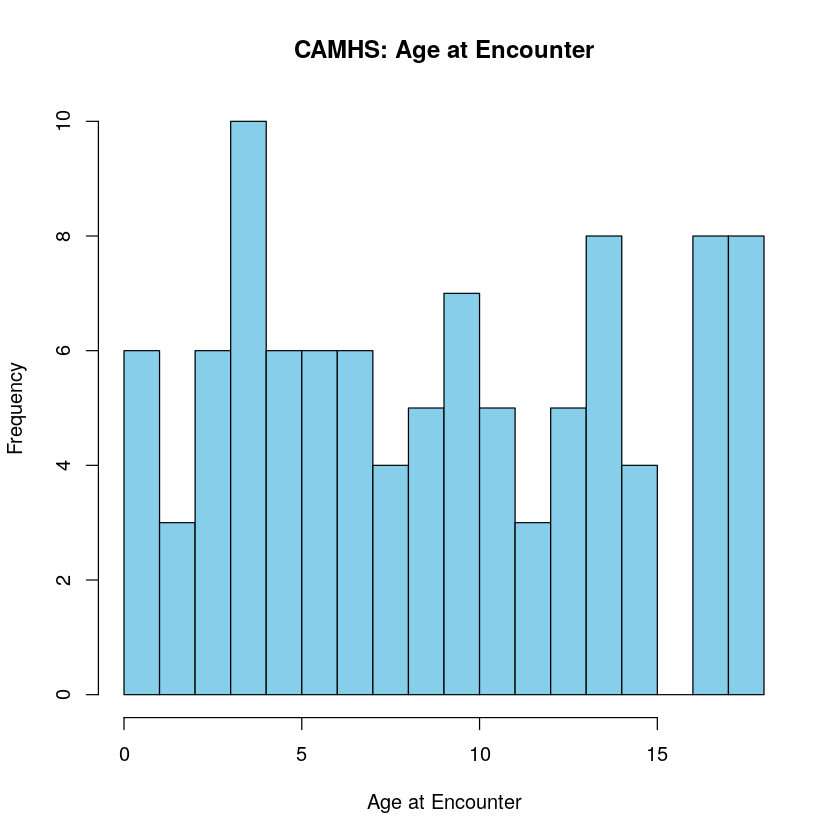

In [15]:
CAMHS <- data.frame(age_at_encounter = sample(1:18, 100, replace = TRUE))


hist(CAMHS$age_at_encounter, 
     col = "skyblue",             # Specify color
     main = "CAMHS: Age at Encounter",   # Title of the plot
     xlab = "Age at Encounter",   # X-axis label
     ylab = "Frequency",          # Y-axis label
     breaks = seq(0, max(CAMHS$age_at_encounter), by = 1))  # Specify breaks


